=== NẠP DỮ LIỆU THÀNH CÔNG VỚI ĐỦ CÁC CỘT CẦN THIẾT ===
=== THỐNG KÊ MÔ TẢ CHI TIẾT ===
              count          mean           std          min           25%  \
Open         1565.0  1.213023e+04  4.648520e+03  3748.631692  9.268331e+03   
High         1565.0  1.226663e+04  4.702566e+03  3929.791954  9.407113e+03   
Low          1565.0  1.199747e+04  4.603409e+03  3665.018738  9.138523e+03   
Close        1565.0  1.212816e+04  4.651862e+03  3776.502197  9.262882e+03   
Volume       1565.0  2.065930e+07  1.443198e+07     0.000000  1.012054e+07   
Log_Return   1565.0  8.816218e-04  1.890060e-02    -0.076210 -6.289270e-03   
Day_of_Week  1565.0  2.000000e+00  1.414666e+00     0.000000  1.000000e+00   

                      50%           75%           max  skewness  kurtosis  
Open         1.189912e+04  1.476611e+04  2.303440e+04  0.449484  0.044882  
High         1.205056e+04  1.498510e+04  2.335208e+04  0.461860  0.076274  
Low          1.176931e+04  1.458183e+04  2.274679e+04  0.44

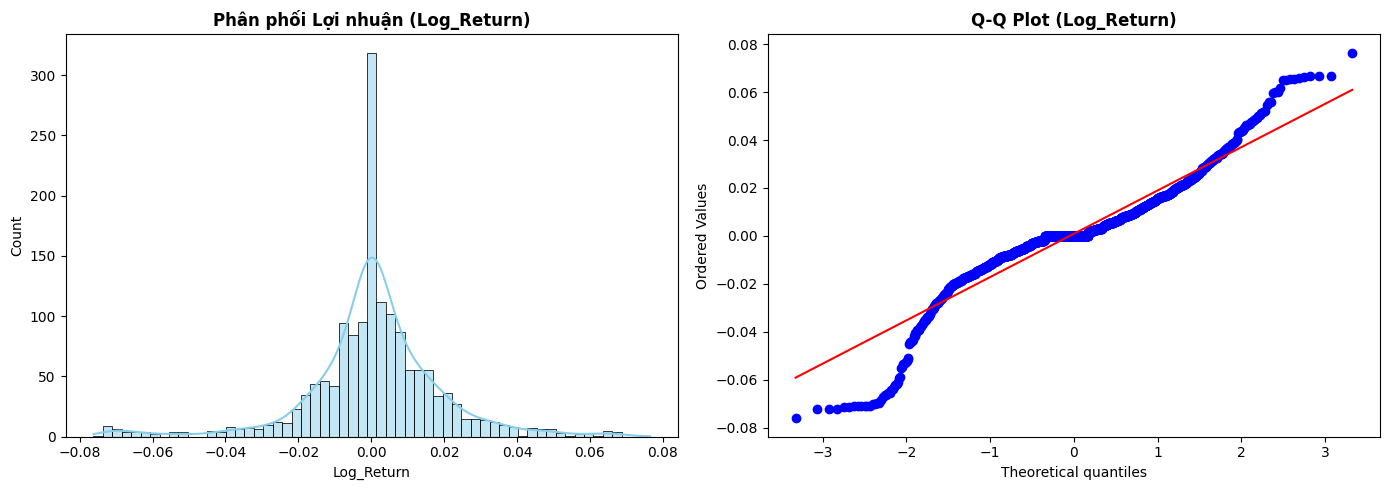

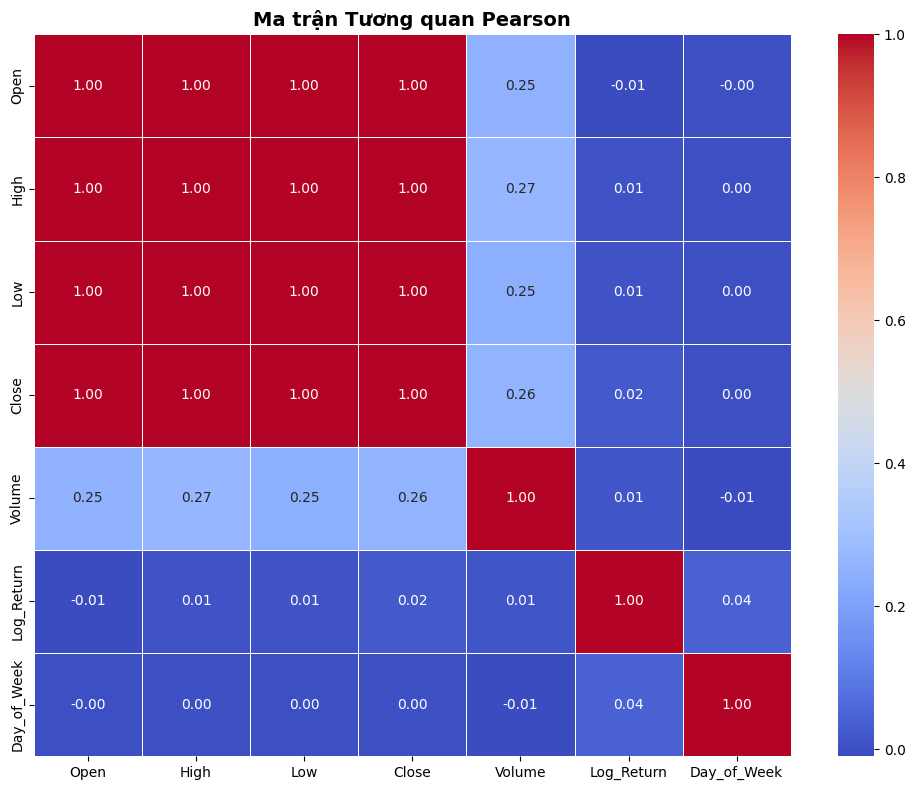

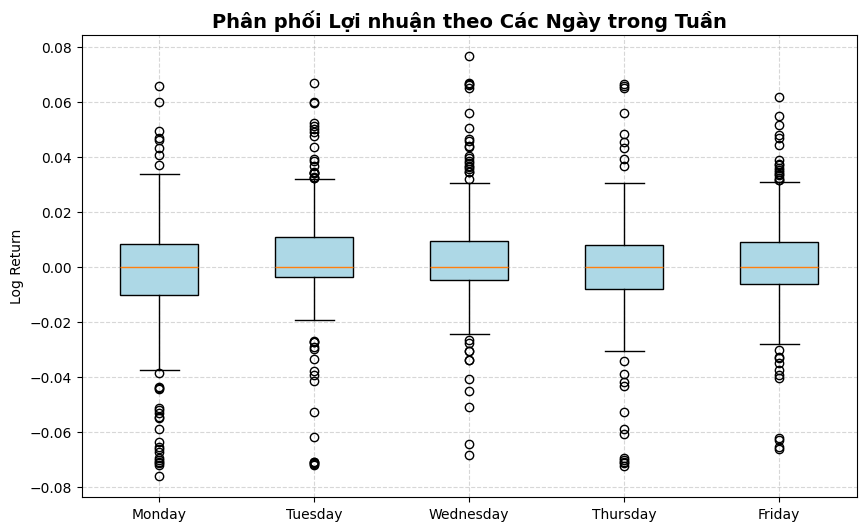

BÁO CÁO PHÂN TÍCH MÙA VỤ & KIỂM ĐỊNH THỐNG KÊ
Kiểm định ANOVA F-test (F-stat = 6.0519): p-value = 0.0001
Kiểm định Kruskal-Wallis (H-stat = 15.7372): p-value = 0.0034
--------------------------------------------------------------------------------
1. Nhận xét: p-value <= 0.05 (Có ý nghĩa thống kê).
2. Giải thích: Tồn tại sự khác biệt có ý nghĩa thống kê về lợi nhuận giữa ít nhất 2 ngày trong tuần.
3. Ý nghĩa: Có dấu hiệu của bất thường mùa vụ (Seasonal Anomaly) trên cổ phiếu này.
4. Kết luận: CÓ THỂ cân nhắc kết hợp biến Ngày trong tuần làm Feature phụ trợ cho mô hình ML.


=== TƯƠNG QUAN GIỮA NGÀY TRONG NĂM VÀ LỢI NHUẬN ===


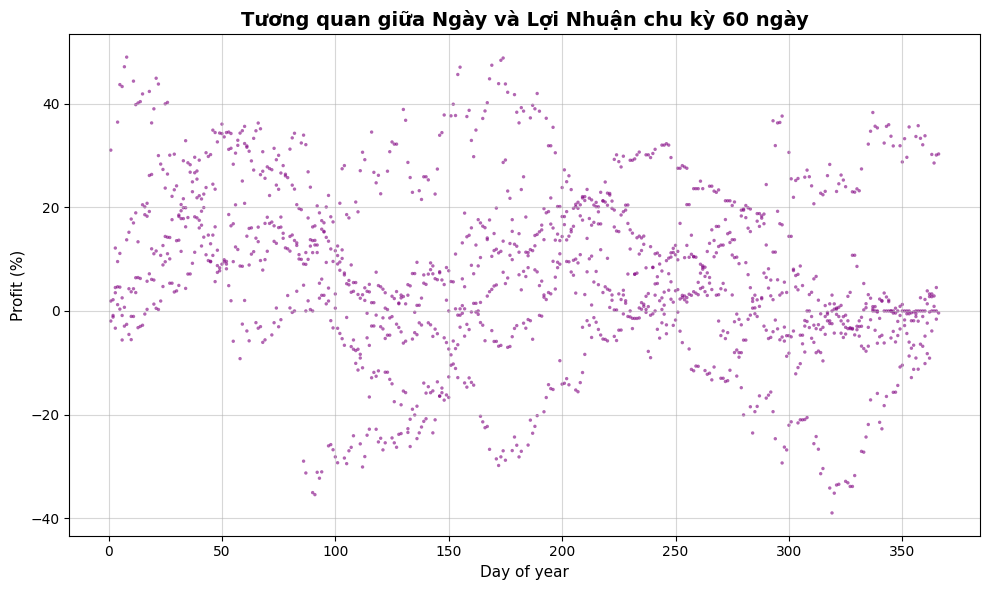


=== TƯƠNG QUAN GIỮA MACD VÀ LỢI NHUẬN ===


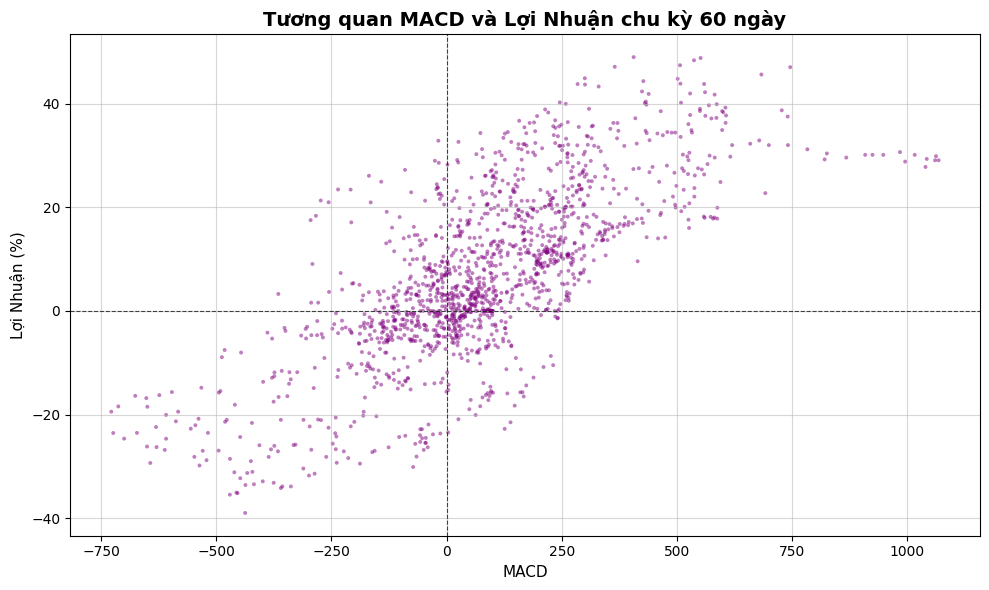

In [1]:
# Cell 1: Import và Nạp Dữ liệu Cleaned
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))
from utils.eda_analyzer import FinancialEDA

# 1. Nạp dữ liệu GAS đã tiền xử lý từ Notebook 03
df_clean = pd.read_parquet("../data/processed/MBB_cleaned.parquet")

# 2. Tạo bổ sung các cột bắt buộc cho phân tích mùa vụ (Seasonality & ANOVA)
# Tính Log Return nếu chưa có
if "Log_Return" not in df_clean.columns:
    df_clean["Log_Return"] = np.log(df_clean["Close"] / df_clean["Close"].shift(1))

# Đảm bảo index là Datetime
df_clean.index = pd.to_datetime(df_clean.index)

# Trích xuất Thứ trong tuần từ Index
if "Day_of_Week" not in df_clean.columns:
    df_clean["Day_of_Week"] = df_clean.index.dayofweek

# Loại bỏ dòng đầu tiên bị NaN do dịch chuyển shift(1)
df_clean.dropna(inplace=True)

# 3. Khởi tạo mô-đun EDA
eda = FinancialEDA(df_clean, target_col="Close")
print("=== NẠP DỮ LIỆU THÀNH CÔNG VỚI ĐỦ CÁC CỘT CẦN THIẾT ===")

# Cell 2: In Báo cáo Thống kê Mô tả Tổng quan
stats_summary = eda.summary_overview()
print("=== THỐNG KÊ MÔ TẢ CHI TIẾT ===")
print(stats_summary)

# Cell 3: Bộ Biểu đồ Phân phối Chi tiết cho Log Return
eda.plot_distribution_suite(col="Log_Return")

# Cell 4: Phân tích Ma trận Tương quan Đa phương pháp
eda.plot_correlations()

# Cell 5: Phân tích Mùa vụ & Kiểm định ANOVA / Kruskal-Wallis
eda.plot_seasonality_and_anova()

# Cell 6: Phân tích Tương quan Mùa vụ dài hạn (Day of Year vs Profit)
print("\n=== TƯƠNG QUAN GIỮA NGÀY TRONG NĂM VÀ LỢI NHUẬN ===")
eda.plot_day_of_year_vs_profit(period=60)

# Cell 7: Phân tích Tương quan Chỉ báo Kỹ thuật (MACD vs Profit)
print("\n=== TƯƠNG QUAN GIỮA MACD VÀ LỢI NHUẬN ===")
eda.plot_macd_vs_profit(period=60)


=== TƯƠNG QUAN GIỮA STOCH_K VÀ LỢI NHUẬN ===


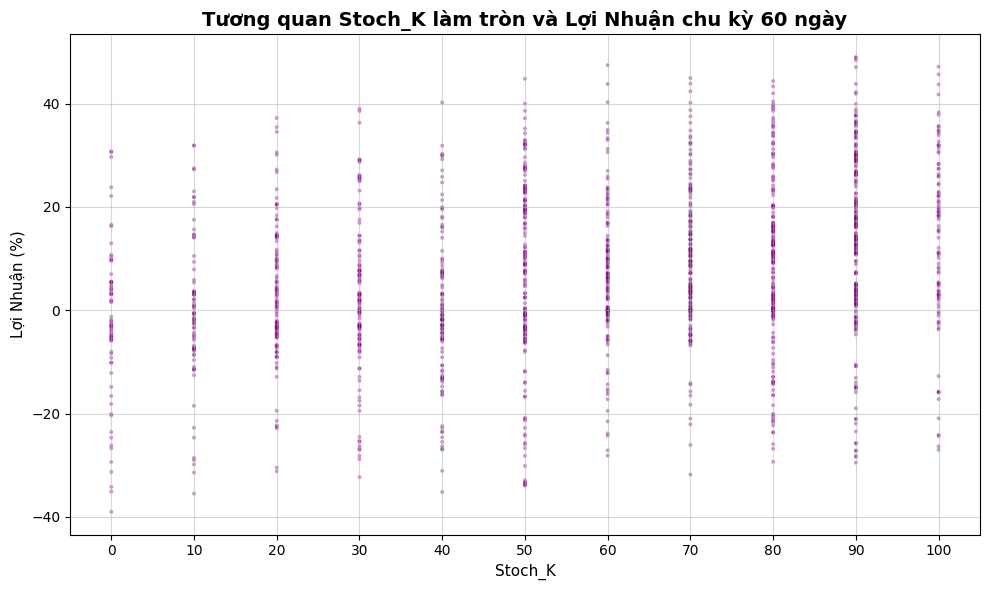

In [2]:
# Cell 11: Phân tích Tương quan giữa Stoch_K làm tròn và Lợi nhuận 60 ngày
print("\n=== TƯƠNG QUAN GIỮA STOCH_K VÀ LỢI NHUẬN ===")
eda.plot_stoch_k_vs_profit(period=60)


=== TƯƠNG QUAN GIỮA RSI LÀM TRÒN VÀ LỢI NHUẬN ===


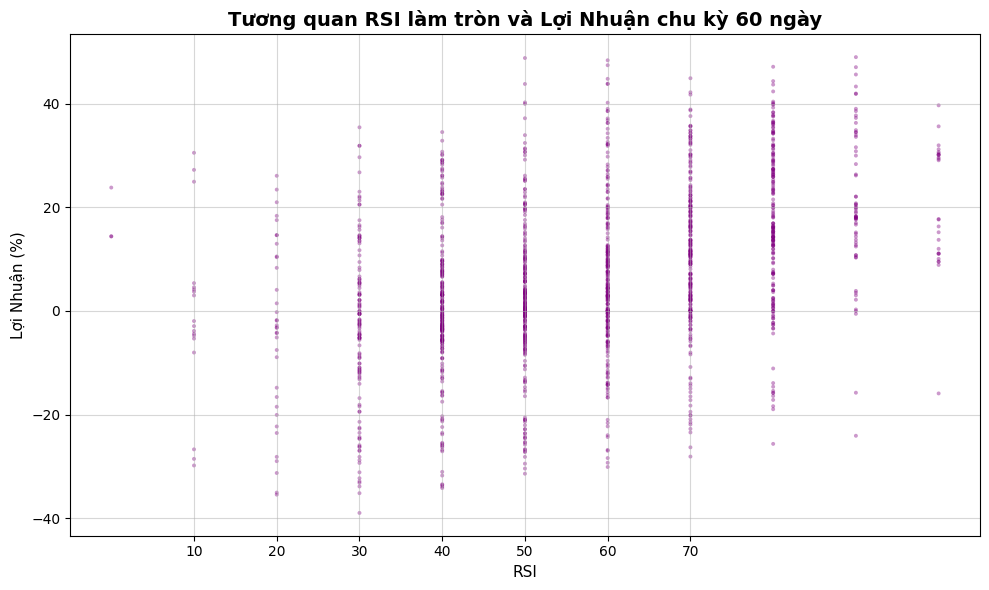

In [3]:
# Cell 8: Phân tích Tương quan RSI làm tròn và Lợi nhuận 60 ngày
print("\n=== TƯƠNG QUAN GIỮA RSI LÀM TRÒN VÀ LỢI NHUẬN ===")
eda.plot_rsi_vs_profit(period=60)


=== TƯƠNG QUAN GIỮA MACD SIGNAL VÀ LỢI NHUẬN ===


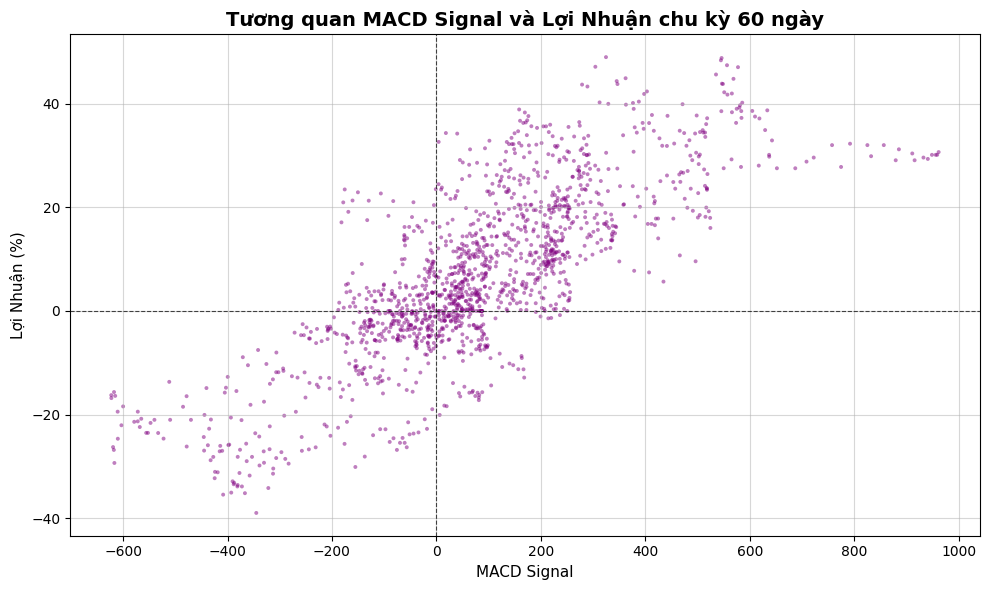

In [4]:
# Cell 9: Phân tích Tương quan MACD Signal và Lợi nhuận 60 ngày
print("\n=== TƯƠNG QUAN GIỮA MACD SIGNAL VÀ LỢI NHUẬN ===")
eda.plot_macd_signal_vs_profit(period=60)


=== TƯƠNG QUAN GIỮA NĂM VÀ LỢI NHUẬN ===


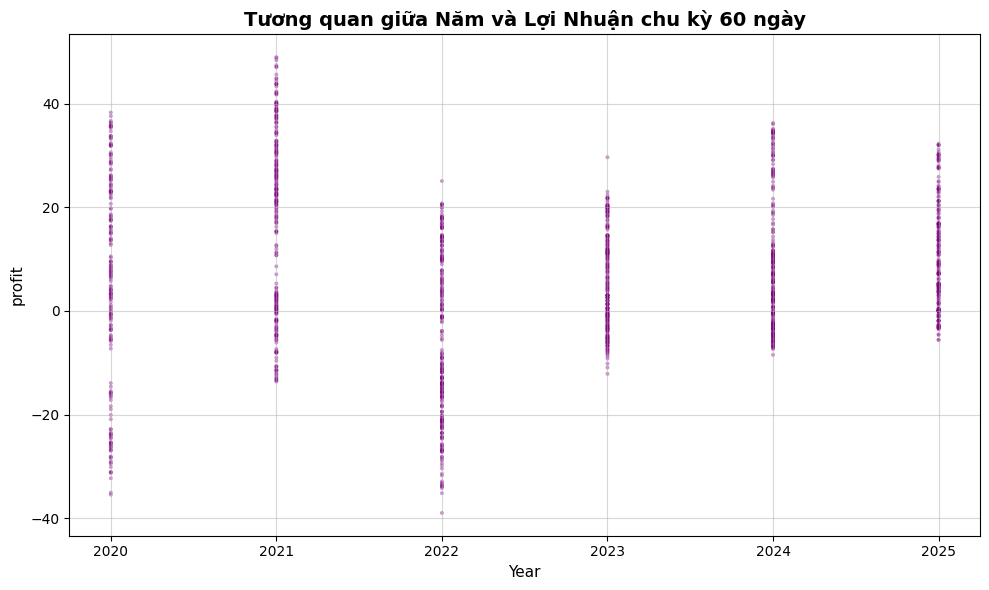

In [5]:
# Cell 10: Phân tích Tương quan giữa Năm và Lợi nhuận 60 ngày
print("\n=== TƯƠNG QUAN GIỮA NĂM VÀ LỢI NHUẬN ===")
eda.plot_year_vs_profit(period=60)